# Sequence Classification: Autoencoder-Based Approach

This notebook compares the CNN encoder approach (from v3) with the LEFR paper's autoencoder approach to improve generalization for tripeptide transfer learning.

## Key Insight from LEFR Paper
Reconstruction loss forces the encoder to learn generalizable spectral features (not just discriminative ones), leading to better transfer performance.

## Architecture Comparison

| Aspect | Current (CNN) | Proposed (Autoencoder) |
|--------|---------------|------------------------|
| Encoder | 1D CNN (Conv1d 1→16→32→64) | FC layers (1023→512→256→latent) |
| Latent dim | 128 | 48 (paper's optimal) |
| Training loss | Cross-entropy only | Reconstruction + Classification |
| Activation | GELU | ReLU (paper) |

## Goal
Improve transfer accuracy from dipeptide→tripeptide evaluation (currently 57.93%).

## 1. Imports and Setup

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import seaborn as sns

# Import our custom modules
from spectra.models import (
    AutoencoderModelConfig,
    AutoencoderDiffClassifier,
    AutoencoderTrainer,
    TrainingConfig,
    train_autoencoder_model,
)

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Device configuration
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# Plot settings
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 10

Using device: cuda


## 2. Constants and Data Loading

In [2]:
# Target amino acid classes (6 classes)
AMINO_ACID_CODES = ['A', 'D', 'F', 'G', 'R', 'S']
CODE_TO_IDX = {code: idx for idx, code in enumerate(AMINO_ACID_CODES)}
IDX_TO_CODE = {idx: code for code, idx in CODE_TO_IDX.items()}

# Full names for display
CODE_TO_NAME = {
    'A': 'Alanine',
    'D': 'Aspartic acid',
    'F': 'Phenylalanine',
    'G': 'Glycine',
    'R': 'Arginine',
    'S': 'Serine'
}

# Mapping from single-letter code to folder name in aminoacids directory
AMINOACID_FOLDER_MAPPING = {
    'A': 'L-Alanine',
    'D': 'L-Aspartic acid',
    'F': 'L-Phenylalanine',
    'G': 'Glycine',
    'R': 'L-Arginine',
    'S': 'L-Serine'
}

# Data loading parameters
MIN_SPECTRA = 5
TARGET_SPECTRA = 200

print(f'Target classes: {AMINO_ACID_CODES}')
print(f'Target spectra per case: {TARGET_SPECTRA}')

Target classes: ['A', 'D', 'F', 'G', 'R', 'S']
Target spectra per case: 200


In [4]:
# Data directories
dipeptide_dir = Path('../data/processed/dipeptides')
aminoacid_dir = Path('../data/processed/aminoacids')
tripeptide_dir = Path('../data/processed/tripeptides')

def resample_to_target(spectra, target_count, random_state=42):
    """Resample spectra to exactly target_count samples."""
    np.random.seed(random_state)
    n_samples = len(spectra)
    
    if n_samples == target_count:
        return spectra.copy()
    elif n_samples > target_count:
        indices = np.random.choice(n_samples, target_count, replace=False)
    else:
        indices = np.random.choice(n_samples, target_count, replace=True)
    
    return spectra[indices]

# Load dipeptide data
dipeptide_data = {}
print(f'Loading dipeptide data (resampling to {TARGET_SPECTRA} spectra each)...')
for folder in sorted(dipeptide_dir.iterdir()):
    if folder.is_dir():
        clean_data_path = folder / 'clean_data.npz'
        if clean_data_path.exists():
            data = np.load(clean_data_path, allow_pickle=True)
            intensities = data['intensities']
            n_spectra = intensities.shape[0]
            if n_spectra >= MIN_SPECTRA:
                resampled = resample_to_target(intensities, TARGET_SPECTRA, 
                                                random_state=42 + len(dipeptide_data))
                dipeptide_data[folder.name] = resampled

print(f'Loaded {len(dipeptide_data)} dipeptides')

Loading dipeptide data (resampling to 200 spectra each)...
Loaded 29 dipeptides


In [5]:
# Load amino acid data
aminoacid_data = {}
print(f'Loading amino acid data (resampling to {TARGET_SPECTRA} spectra each)...')
for code, folder_name in AMINOACID_FOLDER_MAPPING.items():
    folder_path = aminoacid_dir / folder_name
    clean_data_path = folder_path / 'clean_data.npz'
    if clean_data_path.exists():
        data = np.load(clean_data_path, allow_pickle=True)
        intensities = data['intensities']
        n_spectra = intensities.shape[0]
        if n_spectra >= MIN_SPECTRA:
            resampled = resample_to_target(intensities, TARGET_SPECTRA, 
                                            random_state=100 + len(aminoacid_data))
            aminoacid_data[code] = resampled
            print(f'  {code} ({folder_name}): {n_spectra} spectra')

print(f'\nLoaded {len(aminoacid_data)} amino acids')

Loading amino acid data (resampling to 200 spectra each)...
  A (L-Alanine): 2414 spectra
  D (L-Aspartic acid): 1003 spectra
  F (L-Phenylalanine): 2338 spectra
  G (Glycine): 2064 spectra
  R (L-Arginine): 1533 spectra
  S (L-Serine): 2205 spectra

Loaded 6 amino acids


In [6]:
# Load tripeptide data (for transfer evaluation)
tripeptide_data = {}
print('Loading tripeptide data...')
for folder in sorted(tripeptide_dir.iterdir()):
    if folder.is_dir():
        clean_data_path = folder / 'clean_data.npz'
        if clean_data_path.exists():
            data = np.load(clean_data_path, allow_pickle=True)
            intensities = data['intensities']
            n_spectra = intensities.shape[0]
            if n_spectra >= MIN_SPECTRA:
                tripeptide_data[folder.name] = intensities

print(f'Loaded {len(tripeptide_data)} tripeptides')

Loading tripeptide data...
Loaded 33 tripeptides


## 3. Dataset Classes

In [7]:
class LatentDiffDataset(Dataset):
    """Dataset for latent-space differential classification."""
    
    def __init__(self, dipeptide_data, aminoacid_data, seq_length=1023,
                 samples_per_pair=None, max_samples_per_class=None):
        self.pairs = []
        self.pair_info = []
        self.seq_length = seq_length
        
        class_pairs = {i: [] for i in range(len(AMINO_ACID_CODES))}
        
        for dipeptide_name, dipeptide_spectra in dipeptide_data.items():
            first_aa = dipeptide_name[0]
            second_aa = dipeptide_name[1]
            
            if first_aa not in aminoacid_data:
                continue
            if second_aa not in CODE_TO_IDX:
                continue
            
            aa_spectra = aminoacid_data[first_aa]
            label = CODE_TO_IDX[second_aa]
            
            n_dipeptide = len(dipeptide_spectra)
            n_aa = len(aa_spectra)
            n_pairs = min(n_dipeptide, n_aa)
            if samples_per_pair is not None:
                n_pairs = min(n_pairs, samples_per_pair)
            
            dip_indices = np.random.choice(n_dipeptide, n_pairs, replace=False)
            aa_indices = np.random.choice(n_aa, n_pairs, replace=False)
            
            for di, ai in zip(dip_indices, aa_indices):
                class_pairs[label].append((
                    dipeptide_spectra[di],
                    aa_spectra[ai],
                    label,
                    ('dipeptide', dipeptide_name, first_aa, second_aa)
                ))
        
        # Balance classes
        for label, pairs in class_pairs.items():
            if len(pairs) == 0:
                continue
            np.random.shuffle(pairs)
            if max_samples_per_class is not None and len(pairs) > max_samples_per_class:
                pairs = pairs[:max_samples_per_class]
            for dip, aa, lbl, info in pairs:
                self.pairs.append((dip, aa, lbl))
                self.pair_info.append(info)
        
        combined = list(zip(self.pairs, self.pair_info))
        np.random.shuffle(combined)
        self.pairs, self.pair_info = zip(*combined) if combined else ([], [])
        self.pairs = list(self.pairs)
        self.pair_info = list(self.pair_info)
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        dip, aa, label = self.pairs[idx]
        return (
            torch.tensor(dip, dtype=torch.float32),
            torch.tensor(aa, dtype=torch.float32),
            torch.tensor(label, dtype=torch.long)
        )
    
    def get_labels(self):
        return [p[2] for p in self.pairs]
    
    def get_class_distribution(self):
        labels = self.get_labels()
        unique, counts = np.unique(labels, return_counts=True)
        return {IDX_TO_CODE[u]: c for u, c in zip(unique, counts)}


class TripeptideDipeptideDataset(Dataset):
    """Dataset for tripeptide-dipeptide evaluation."""
    
    def __init__(self, tripeptide_data, dipeptide_data, samples_per_pair=None):
        self.pairs = []
        self.pair_info = []
        
        for tripeptide_name, tripeptide_spectra in tripeptide_data.items():
            xy = tripeptide_name[:2]
            z = tripeptide_name[2]
            
            if xy not in dipeptide_data:
                continue
            if z not in CODE_TO_IDX:
                continue
            
            dipeptide_spectra = dipeptide_data[xy]
            label = CODE_TO_IDX[z]
            
            n_tripeptide = len(tripeptide_spectra)
            n_dipeptide = len(dipeptide_spectra)
            n_pairs = min(n_tripeptide, n_dipeptide)
            if samples_per_pair is not None:
                n_pairs = min(n_pairs, samples_per_pair)
            
            tri_indices = np.random.choice(n_tripeptide, n_pairs, replace=False)
            dip_indices = np.random.choice(n_dipeptide, n_pairs, replace=False)
            
            for ti, di in zip(tri_indices, dip_indices):
                self.pairs.append((tripeptide_spectra[ti], dipeptide_spectra[di], label))
                self.pair_info.append(('tripeptide', tripeptide_name, xy, z))
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        tri, dip, label = self.pairs[idx]
        return (
            torch.tensor(tri, dtype=torch.float32),
            torch.tensor(dip, dtype=torch.float32),
            torch.tensor(label, dtype=torch.long)
        )
    
    def get_class_distribution(self):
        labels = [p[2] for p in self.pairs]
        unique, counts = np.unique(labels, return_counts=True)
        return {IDX_TO_CODE[u]: c for u, c in zip(unique, counts)}

In [8]:
# Create datasets
print('Creating training dataset...')
dataset = LatentDiffDataset(
    dipeptide_data, 
    aminoacid_data,
    seq_length=1023,
    samples_per_pair=None,
    max_samples_per_class=1000,
)
print(f'Total training samples: {len(dataset)}')

class_dist = dataset.get_class_distribution()
print('\nClass distribution:')
for code, count in sorted(class_dist.items()):
    print(f'  {code} ({CODE_TO_NAME[code]}): {count} samples')

Creating training dataset...
Total training samples: 5800

Class distribution:
  A (Alanine): 1000 samples
  D (Aspartic acid): 1000 samples
  F (Phenylalanine): 1000 samples
  G (Glycine): 1000 samples
  R (Arginine): 1000 samples
  S (Serine): 800 samples


In [9]:
# Create tripeptide evaluation dataset
print('\nCreating tripeptide evaluation dataset...')
tripeptide_eval_dataset = TripeptideDipeptideDataset(
    tripeptide_data,
    dipeptide_data,
    samples_per_pair=50
)
print(f'Total tripeptide evaluation samples: {len(tripeptide_eval_dataset)}')


Creating tripeptide evaluation dataset...
Total tripeptide evaluation samples: 1557


In [10]:
# Stratified train/val split
labels = dataset.get_labels()
indices = list(range(len(dataset)))

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

train_subset = Subset(dataset, train_indices)
val_subset = Subset(dataset, val_indices)

print(f'Training samples: {len(train_subset)}')
print(f'Validation samples: {len(val_subset)}')

Training samples: 4640
Validation samples: 1160


## 4. Baseline CNN Model (from v3)

First, let's reproduce the baseline CNN results for comparison.

In [11]:
class LatentDiffClassifier(nn.Module):
    """Baseline CNN classifier (from v3)."""
    
    def __init__(self, seq_length=1023, d_model=64, latent_dim=128, num_classes=6, dropout=0.3):
        super().__init__()
        
        self.seq_length = seq_length
        self.d_model = d_model
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        
        # Shared encoder: spectrum → latent representation
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3),
            nn.BatchNorm1d(16),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.MaxPool1d(2),
            
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.MaxPool1d(2),
            
            nn.Conv1d(32, d_model, kernel_size=3, padding=1),
            nn.BatchNorm1d(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.AdaptiveAvgPool1d(16),
        )
        
        self.to_latent = nn.Sequential(
            nn.Flatten(),
            nn.Linear(d_model * 16, latent_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, latent_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout + 0.1),
            nn.Linear(latent_dim // 2, num_classes),
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
    
    def encode(self, spectrum):
        x = spectrum.unsqueeze(1)
        x = self.encoder(x)
        z = self.to_latent(x)
        return z
    
    def forward(self, spectrum_dipeptide, spectrum_aminoacid):
        z_dip = self.encode(spectrum_dipeptide)
        z_aa = self.encode(spectrum_aminoacid)
        z_diff = z_dip - z_aa
        logits = self.classifier(z_diff)
        return logits
    
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

## 5. Autoencoder Model Experiments

Now let's test the autoencoder approach with different configurations.

In [12]:
def collate_fn(batch):
    """Custom collate function for paired data."""
    s_xy = torch.stack([b[0] for b in batch])
    s_x = torch.stack([b[1] for b in batch])
    labels = torch.stack([b[2] for b in batch])
    return s_xy, s_x, labels


def evaluate_model(model, data_loader, device):
    """Evaluate model and return accuracy and predictions."""
    model.eval()
    all_predictions = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for s_xy, s_x, labels in data_loader:
            s_xy, s_x = s_xy.to(device), s_x.to(device)
            
            if hasattr(model, 'predict'):
                outputs = model.predict(s_xy, s_x)
            else:
                outputs = model(s_xy, s_x)
            
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    
    accuracy = 100.0 * np.mean(np.array(all_predictions) == np.array(all_labels))
    return accuracy, np.array(all_predictions), np.array(all_labels), np.array(all_probs)


def train_and_evaluate(model, train_subset, val_subset, tripeptide_loader, 
                       config, device, model_name, is_autoencoder=False,
                       recon_weight=1.0, class_weight=1.0, pretrain_epochs=0):
    """Train model and evaluate on validation and tripeptide data."""
    print(f'\n{"="*70}')
    print(f'Training: {model_name}')
    print(f'{"="*70}')
    print(f'Parameters: {model.count_parameters():,}')
    
    if is_autoencoder:
        model, history = train_autoencoder_model(
            model=model,
            train_dataset=train_subset,
            val_dataset=val_subset,
            config=config,
            reconstruction_weight=recon_weight,
            classification_weight=class_weight,
            pretrain_epochs=pretrain_epochs,
            verbose=True,
        )
    else:
        # Train baseline CNN
        train_loader = DataLoader(train_subset, batch_size=config.batch_size, 
                                  shuffle=True, collate_fn=collate_fn)
        val_loader = DataLoader(val_subset, batch_size=config.batch_size, 
                                shuffle=False, collate_fn=collate_fn)
        
        model = model.to(device)
        criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
        optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate, 
                                      weight_decay=config.weight_decay)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
        )
        
        history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
        best_val_loss = float('inf')
        best_state = None
        patience_counter = 0
        
        for epoch in range(config.epochs):
            # Training
            model.train()
            train_loss = 0
            correct = 0
            total = 0
            
            for s_xy, s_x, labels in train_loader:
                s_xy, s_x, labels = s_xy.to(device), s_x.to(device), labels.to(device)
                
                optimizer.zero_grad()
                outputs = model(s_xy, s_x)
                loss = criterion(outputs, labels)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                
                train_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
            
            train_loss /= len(train_loader)
            train_acc = 100.0 * correct / total
            
            # Validation
            model.eval()
            val_loss = 0
            correct = 0
            total = 0
            
            with torch.no_grad():
                for s_xy, s_x, labels in val_loader:
                    s_xy, s_x, labels = s_xy.to(device), s_x.to(device), labels.to(device)
                    outputs = model(s_xy, s_x)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item()
                    _, predicted = outputs.max(1)
                    total += labels.size(0)
                    correct += predicted.eq(labels).sum().item()
            
            val_loss /= len(val_loader)
            val_acc = 100.0 * correct / total
            
            scheduler.step(val_loss)
            
            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            history['train_acc'].append(train_acc)
            history['val_acc'].append(val_acc)
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1
            
            if (epoch + 1) % 10 == 0:
                print(f'Epoch {epoch+1:3d}: Train Loss={train_loss:.4f}, Acc={train_acc:.1f}% | '
                      f'Val Loss={val_loss:.4f}, Acc={val_acc:.1f}%')
            
            if patience_counter >= config.early_stopping_patience:
                print(f'Early stopping at epoch {epoch+1}')
                break
        
        if best_state is not None:
            model.load_state_dict(best_state)
    
    # Evaluate
    val_loader = DataLoader(val_subset, batch_size=config.batch_size, 
                            shuffle=False, collate_fn=collate_fn)
    val_acc, val_preds, val_labels, _ = evaluate_model(model, val_loader, device)
    tri_acc, tri_preds, tri_labels, _ = evaluate_model(model, tripeptide_loader, device)
    
    print(f'\nResults for {model_name}:')
    print(f'  Validation Accuracy: {val_acc:.2f}%')
    print(f'  Tripeptide Transfer Accuracy: {tri_acc:.2f}%')
    print(f'  Generalization Gap: {val_acc - tri_acc:.2f}%')
    
    return model, history, {
        'val_acc': val_acc,
        'tri_acc': tri_acc,
        'val_preds': val_preds,
        'val_labels': val_labels,
        'tri_preds': tri_preds,
        'tri_labels': tri_labels,
    }

In [14]:
# Create data loaders
batch_size = 32

tripeptide_loader = DataLoader(
    tripeptide_eval_dataset, 
    batch_size=batch_size, 
    shuffle=False, 
    collate_fn=collate_fn
)

# Training configuration
training_config = TrainingConfig(
    learning_rate=0.0001,
    weight_decay=1e-4,
    epochs=50,
    batch_size=batch_size,
    early_stopping_patience=100,
    device=device,
)

print(f'Training config: lr={training_config.learning_rate}, epochs={training_config.epochs}')

Training config: lr=0.0001, epochs=50


### 5.1 Baseline CNN (latent_dim=128)

In [15]:
# Baseline CNN model
baseline_model = LatentDiffClassifier(
    seq_length=1023,
    d_model=64,
    latent_dim=128,
    num_classes=6,
    dropout=0.3
)

baseline_model, baseline_history, baseline_results = train_and_evaluate(
    model=baseline_model,
    train_subset=train_subset,
    val_subset=val_subset,
    tripeptide_loader=tripeptide_loader,
    config=training_config,
    device=device,
    model_name='Baseline CNN (latent_dim=128)',
    is_autoencoder=False,
)


Training: Baseline CNN (latent_dim=128)
Parameters: 148,998
Epoch  10: Train Loss=0.6553, Acc=93.1% | Val Loss=0.6884, Acc=92.4%
Epoch  20: Train Loss=0.5556, Acc=97.7% | Val Loss=0.6015, Acc=97.3%
Epoch  30: Train Loss=0.5235, Acc=98.8% | Val Loss=0.5655, Acc=97.4%
Epoch  40: Train Loss=0.5056, Acc=99.4% | Val Loss=0.5434, Acc=98.5%
Epoch  50: Train Loss=0.4951, Acc=99.6% | Val Loss=0.5213, Acc=99.0%

Results for Baseline CNN (latent_dim=128):
  Validation Accuracy: 99.31%
  Tripeptide Transfer Accuracy: 59.15%
  Generalization Gap: 40.16%


### 5.2 Autoencoder with Joint Training (latent_dim=48)

In [16]:
# Autoencoder model with latent_dim=48 (LEFR paper optimal)
ae_config_48 = AutoencoderModelConfig(
    seq_length=1023,
    encoder_dims=(512, 256),
    latent_dim=48,
    dropout=0.3,
    num_classes=6,
    activation='relu',
    reconstruction_weight=1.0,
    classification_weight=1.0,
)

ae_model_48 = AutoencoderDiffClassifier(ae_config_48)

ae_model_48, ae_history_48, ae_results_48 = train_and_evaluate(
    model=ae_model_48,
    train_subset=train_subset,
    val_subset=val_subset,
    tripeptide_loader=tripeptide_loader,
    config=training_config,
    device=device,
    model_name='Autoencoder (latent_dim=48, joint)',
    is_autoencoder=True,
    recon_weight=1.0,
    class_weight=1.0,
)


Training: Autoencoder (latent_dim=48, joint)
Parameters: 1,342,597
Training AutoencoderDiffClassifier on cuda
Train samples: 4640
Val samples: 1160
Model parameters: 1,342,597
Loss weights: recon=1.0, class=1.0
----------------------------------------------------------------------
Epoch   1/50 | Loss: 1.8511 (R:0.3094 C:1.5416) | Val: 0.7907 (R:0.0380 C:0.7527) | Acc: 49.0%/88.1% | LR: 1.00e-04
Epoch   2/50 | Loss: 1.1366 (R:0.1753 C:0.9613) | Val: 0.6222 (R:0.0180 C:0.6043) | Acc: 76.9%/92.2% | LR: 1.00e-04
Epoch   3/50 | Loss: 0.9081 (R:0.1053 C:0.8027) | Val: 0.5678 (R:0.0102 C:0.5576) | Acc: 87.0%/96.1% | LR: 1.00e-04
Epoch   4/50 | Loss: 0.7931 (R:0.0642 C:0.7289) | Val: 0.5436 (R:0.0072 C:0.5365) | Acc: 91.0%/95.9% | LR: 1.00e-04
Epoch   5/50 | Loss: 0.7346 (R:0.0416 C:0.6930) | Val: 0.5266 (R:0.0059 C:0.5208) | Acc: 93.2%/96.1% | LR: 1.00e-04
Epoch   6/50 | Loss: 0.7002 (R:0.0288 C:0.6714) | Val: 0.5212 (R:0.0052 C:0.5160) | Acc: 93.8%/96.2% | LR: 1.00e-04
Epoch   7/50 | Loss: 

### 5.3 Autoencoder with latent_dim=64

In [17]:
# Autoencoder model with latent_dim=64
ae_config_64 = AutoencoderModelConfig(
    seq_length=1023,
    encoder_dims=(512, 256),
    latent_dim=64,
    dropout=0.3,
    num_classes=6,
    activation='relu',
    reconstruction_weight=1.0,
    classification_weight=1.0,
)

ae_model_64 = AutoencoderDiffClassifier(ae_config_64)

ae_model_64, ae_history_64, ae_results_64 = train_and_evaluate(
    model=ae_model_64,
    train_subset=train_subset,
    val_subset=val_subset,
    tripeptide_loader=tripeptide_loader,
    config=training_config,
    device=device,
    model_name='Autoencoder (latent_dim=64, joint)',
    is_autoencoder=True,
    recon_weight=1.0,
    class_weight=1.0,
)


Training: Autoencoder (latent_dim=64, joint)
Parameters: 1,352,709
Training AutoencoderDiffClassifier on cuda
Train samples: 4640
Val samples: 1160
Model parameters: 1,352,709
Loss weights: recon=1.0, class=1.0
----------------------------------------------------------------------
Epoch   1/50 | Loss: 1.8181 (R:0.3125 C:1.5056) | Val: 0.7691 (R:0.0382 C:0.7308) | Acc: 53.0%/90.9% | LR: 1.00e-04
Epoch   2/50 | Loss: 1.0758 (R:0.1739 C:0.9019) | Val: 0.6350 (R:0.0179 C:0.6171) | Acc: 81.5%/94.7% | LR: 1.00e-04
Epoch   3/50 | Loss: 0.8778 (R:0.1008 C:0.7769) | Val: 0.5682 (R:0.0097 C:0.5585) | Acc: 89.3%/96.0% | LR: 1.00e-04
Epoch   4/50 | Loss: 0.7640 (R:0.0607 C:0.7033) | Val: 0.5324 (R:0.0069 C:0.5255) | Acc: 92.6%/97.8% | LR: 1.00e-04
Epoch   5/50 | Loss: 0.7190 (R:0.0403 C:0.6788) | Val: 0.5177 (R:0.0060 C:0.5118) | Acc: 93.7%/97.9% | LR: 1.00e-04
Epoch   6/50 | Loss: 0.6718 (R:0.0288 C:0.6431) | Val: 0.5016 (R:0.0054 C:0.4962) | Acc: 95.3%/98.4% | LR: 1.00e-04
Epoch   7/50 | Loss: 

### 5.4 Autoencoder with latent_dim=128

In [18]:
# Autoencoder model with latent_dim=128
ae_config_128 = AutoencoderModelConfig(
    seq_length=1023,
    encoder_dims=(512, 256),
    latent_dim=128,
    dropout=0.3,
    num_classes=6,
    activation='relu',
    reconstruction_weight=1.0,
    classification_weight=1.0,
)

ae_model_128 = AutoencoderDiffClassifier(ae_config_128)

ae_model_128, ae_history_128, ae_results_128 = train_and_evaluate(
    model=ae_model_128,
    train_subset=train_subset,
    val_subset=val_subset,
    tripeptide_loader=tripeptide_loader,
    config=training_config,
    device=device,
    model_name='Autoencoder (latent_dim=128, joint)',
    is_autoencoder=True,
    recon_weight=1.0,
    class_weight=1.0,
)


Training: Autoencoder (latent_dim=128, joint)
Parameters: 1,398,277
Training AutoencoderDiffClassifier on cuda
Train samples: 4640
Val samples: 1160
Model parameters: 1,398,277
Loss weights: recon=1.0, class=1.0
----------------------------------------------------------------------
Epoch   1/50 | Loss: 1.7493 (R:0.3140 C:1.4354) | Val: 0.8021 (R:0.0409 C:0.7612) | Acc: 54.0%/86.6% | LR: 1.00e-04
Epoch   2/50 | Loss: 1.0024 (R:0.1695 C:0.8329) | Val: 0.6708 (R:0.0172 C:0.6536) | Acc: 84.4%/87.6% | LR: 1.00e-04
Epoch   3/50 | Loss: 0.8154 (R:0.0897 C:0.7257) | Val: 0.5959 (R:0.0098 C:0.5862) | Acc: 91.1%/93.3% | LR: 1.00e-04
Epoch   4/50 | Loss: 0.7134 (R:0.0521 C:0.6613) | Val: 0.5806 (R:0.0069 C:0.5736) | Acc: 94.2%/94.6% | LR: 1.00e-04
Epoch   5/50 | Loss: 0.6659 (R:0.0352 C:0.6307) | Val: 0.5437 (R:0.0058 C:0.5378) | Acc: 95.3%/96.4% | LR: 1.00e-04
Epoch   6/50 | Loss: 0.6375 (R:0.0259 C:0.6117) | Val: 0.5357 (R:0.0053 C:0.5304) | Acc: 96.4%/97.2% | LR: 1.00e-04
Epoch   7/50 | Loss:

### 5.5 Autoencoder with Pre-training

In [19]:
# Autoencoder with pre-training strategy
ae_config_pretrain = AutoencoderModelConfig(
    seq_length=1023,
    encoder_dims=(512, 256),
    latent_dim=48,
    dropout=0.3,
    num_classes=6,
    activation='relu',
    reconstruction_weight=1.0,
    classification_weight=1.0,
)

ae_model_pretrain = AutoencoderDiffClassifier(ae_config_pretrain)

ae_model_pretrain, ae_history_pretrain, ae_results_pretrain = train_and_evaluate(
    model=ae_model_pretrain,
    train_subset=train_subset,
    val_subset=val_subset,
    tripeptide_loader=tripeptide_loader,
    config=training_config,
    device=device,
    model_name='Autoencoder (latent_dim=48, pretrain+finetune)',
    is_autoencoder=True,
    recon_weight=1.0,
    class_weight=1.0,
    pretrain_epochs=30,
)


Training: Autoencoder (latent_dim=48, pretrain+finetune)
Parameters: 1,342,597
Pre-training autoencoder (reconstruction only)...
------------------------------------------------------------
Pretrain Epoch  10/30 | Recon: 0.018259 | Val Recon: 0.007216
Pretrain Epoch  20/30 | Recon: 0.008586 | Val Recon: 0.004959
Pretrain Epoch  30/30 | Recon: 0.005884 | Val Recon: 0.003184
Pre-training complete.

Training AutoencoderDiffClassifier on cuda
Train samples: 4640
Val samples: 1160
Model parameters: 1,342,597
Loss weights: recon=1.0, class=1.0
----------------------------------------------------------------------
Epoch   1/50 | Loss: 1.4804 (R:0.0089 C:1.4715) | Val: 0.7114 (R:0.0047 C:0.7068) | Acc: 62.1%/93.9% | LR: 1.00e-04
Epoch   2/50 | Loss: 0.8320 (R:0.0102 C:0.8218) | Val: 0.5768 (R:0.0048 C:0.5721) | Acc: 87.4%/95.9% | LR: 1.00e-04
Epoch   3/50 | Loss: 0.7473 (R:0.0097 C:0.7376) | Val: 0.5516 (R:0.0050 C:0.5467) | Acc: 91.3%/96.0% | LR: 1.00e-04
Epoch   4/50 | Loss: 0.6982 (R:0.008

### 5.6 Autoencoder with Higher Reconstruction Weight

In [20]:
# Autoencoder with higher reconstruction weight
ae_config_high_recon = AutoencoderModelConfig(
    seq_length=1023,
    encoder_dims=(512, 256),
    latent_dim=48,
    dropout=0.3,
    num_classes=6,
    activation='relu',
    reconstruction_weight=2.0,
    classification_weight=1.0,
)

ae_model_high_recon = AutoencoderDiffClassifier(ae_config_high_recon)

ae_model_high_recon, ae_history_high_recon, ae_results_high_recon = train_and_evaluate(
    model=ae_model_high_recon,
    train_subset=train_subset,
    val_subset=val_subset,
    tripeptide_loader=tripeptide_loader,
    config=training_config,
    device=device,
    model_name='Autoencoder (latent_dim=48, recon_weight=2.0)',
    is_autoencoder=True,
    recon_weight=2.0,
    class_weight=1.0,
)


Training: Autoencoder (latent_dim=48, recon_weight=2.0)
Parameters: 1,342,597
Training AutoencoderDiffClassifier on cuda
Train samples: 4640
Val samples: 1160
Model parameters: 1,342,597
Loss weights: recon=2.0, class=1.0
----------------------------------------------------------------------
Epoch   1/50 | Loss: 2.1805 (R:0.3109 C:1.5588) | Val: 0.8227 (R:0.0387 C:0.7454) | Acc: 50.0%/87.2% | LR: 1.00e-04
Epoch   2/50 | Loss: 1.3244 (R:0.1717 C:0.9810) | Val: 0.7230 (R:0.0179 C:0.6873) | Acc: 77.1%/87.3% | LR: 1.00e-04
Epoch   3/50 | Loss: 1.0513 (R:0.0963 C:0.8586) | Val: 0.6555 (R:0.0102 C:0.6351) | Acc: 84.4%/91.2% | LR: 1.00e-04
Epoch   4/50 | Loss: 0.8792 (R:0.0547 C:0.7697) | Val: 0.6094 (R:0.0069 C:0.5955) | Acc: 89.0%/94.5% | LR: 1.00e-04
Epoch   5/50 | Loss: 0.7903 (R:0.0336 C:0.7230) | Val: 0.5746 (R:0.0060 C:0.5627) | Acc: 91.6%/95.5% | LR: 1.00e-04
Epoch   6/50 | Loss: 0.7447 (R:0.0239 C:0.6969) | Val: 0.5500 (R:0.0056 C:0.5387) | Acc: 93.2%/95.8% | LR: 1.00e-04
Epoch   7/

## 6. Results Comparison

In [21]:
# Collect all results
all_results = {
    'Baseline CNN (128)': baseline_results,
    'AE (48, joint)': ae_results_48,
    'AE (64, joint)': ae_results_64,
    'AE (128, joint)': ae_results_128,
    'AE (48, pretrain)': ae_results_pretrain,
    'AE (48, recon=2)': ae_results_high_recon,
}

# Create comparison table
print('\n' + '='*80)
print('RESULTS COMPARISON')
print('='*80)
print(f'{"Model":<25} {"Val Acc":>12} {"Transfer Acc":>14} {"Gen. Gap":>12}')
print('-'*80)

for name, results in all_results.items():
    gap = results['val_acc'] - results['tri_acc']
    print(f'{name:<25} {results["val_acc"]:>11.2f}% {results["tri_acc"]:>13.2f}% {gap:>11.2f}%')

print('='*80)


RESULTS COMPARISON
Model                          Val Acc   Transfer Acc     Gen. Gap
--------------------------------------------------------------------------------
Baseline CNN (128)              99.31%         59.15%       40.16%
AE (48, joint)                  98.79%         61.46%       37.33%
AE (64, joint)                  99.14%         63.78%       35.36%
AE (128, joint)                 99.48%         61.59%       37.89%
AE (48, pretrain)               98.71%         62.24%       36.47%
AE (48, recon=2)                99.22%         60.57%       38.66%


C:\Users\mfarzi\AppData\Local\Temp\ipykernel_60204\2172416071.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(model_names, rotation=45, ha='right')


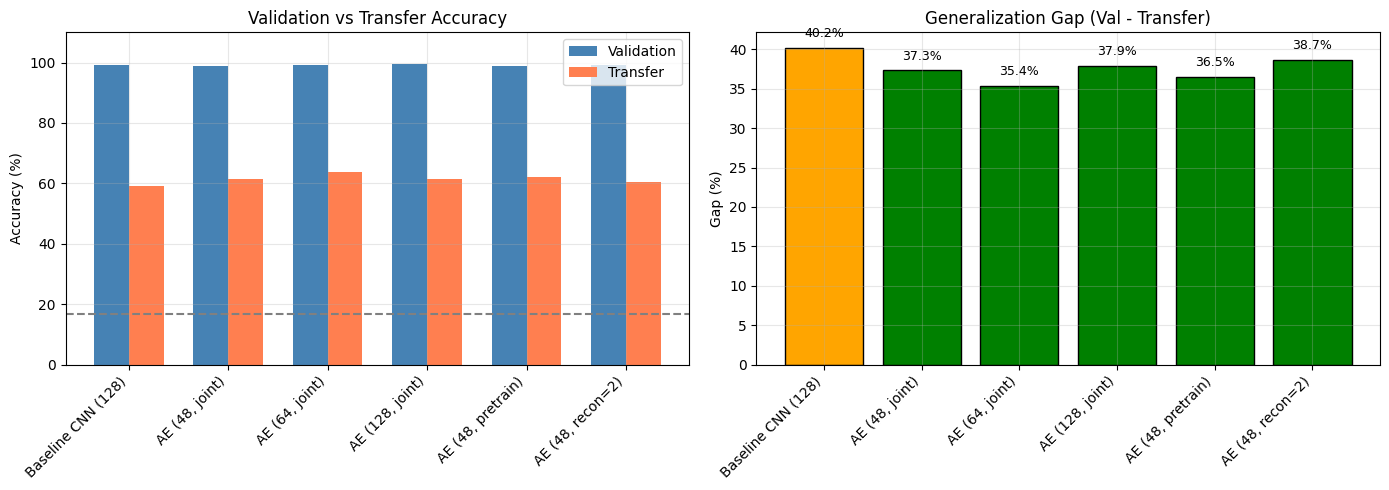

In [22]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = list(all_results.keys())
val_accs = [all_results[name]['val_acc'] for name in model_names]
tri_accs = [all_results[name]['tri_acc'] for name in model_names]

x = np.arange(len(model_names))
width = 0.35

# Accuracy comparison
axes[0].bar(x - width/2, val_accs, width, label='Validation', color='steelblue')
axes[0].bar(x + width/2, tri_accs, width, label='Transfer', color='coral')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Validation vs Transfer Accuracy')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=45, ha='right')
axes[0].legend()
axes[0].axhline(y=100/6, color='gray', linestyle='--', label='Random')
axes[0].set_ylim(0, 110)
axes[0].grid(True, alpha=0.3)

# Generalization gap
gaps = [val - tri for val, tri in zip(val_accs, tri_accs)]
colors = ['green' if g < 40 else 'orange' if g < 45 else 'red' for g in gaps]
axes[1].bar(model_names, gaps, color=colors, edgecolor='black')
axes[1].set_ylabel('Gap (%)')
axes[1].set_title('Generalization Gap (Val - Transfer)')
axes[1].set_xticklabels(model_names, rotation=45, ha='right')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].grid(True, alpha=0.3)

for i, g in enumerate(gaps):
    axes[1].text(i, g + 1, f'{g:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Reconstruction Quality Visualization

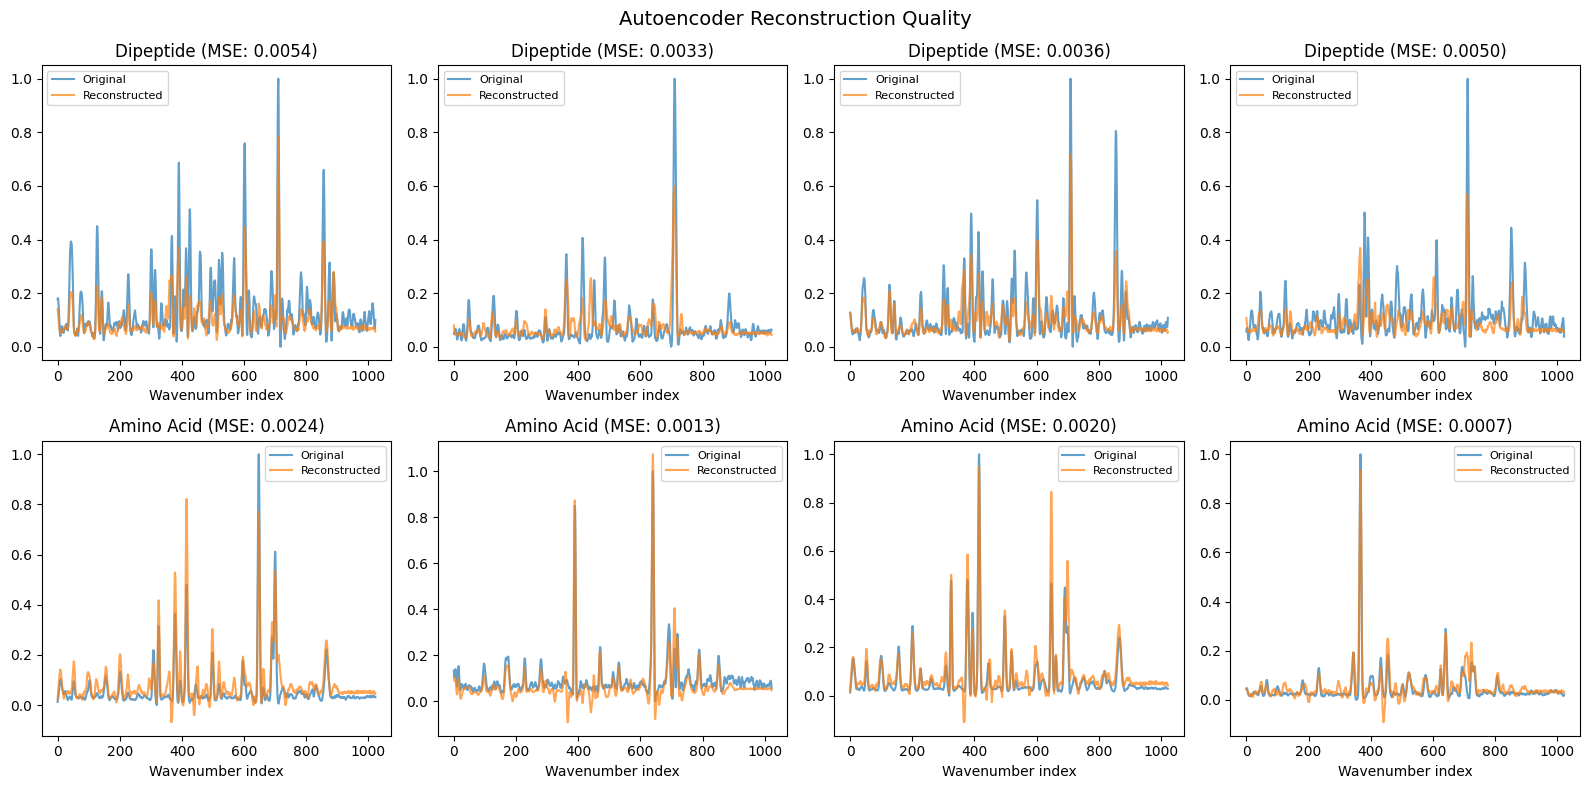

In [23]:
# Visualize reconstruction quality for the best autoencoder model
best_ae_model = ae_model_48  # Use the model with latent_dim=48
best_ae_model.eval()

# Get some sample spectra
val_loader = DataLoader(val_subset, batch_size=8, shuffle=True, collate_fn=collate_fn)
sample_batch = next(iter(val_loader))
s_xy, s_x, labels = sample_batch
s_xy, s_x = s_xy.to(device), s_x.to(device)

with torch.no_grad():
    logits, recon_xy, recon_x, z_xy, z_x = best_ae_model(s_xy, s_x, return_reconstructions=True)

# Convert to numpy
s_xy_np = s_xy.cpu().numpy()
s_x_np = s_x.cpu().numpy()
recon_xy_np = recon_xy.cpu().numpy()
recon_x_np = recon_x.cpu().numpy()

# Plot reconstructions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    # Dipeptide spectrum
    axes[0, i].plot(s_xy_np[i], label='Original', alpha=0.7)
    axes[0, i].plot(recon_xy_np[i], label='Reconstructed', alpha=0.7)
    mse = np.mean((s_xy_np[i] - recon_xy_np[i])**2)
    axes[0, i].set_title(f'Dipeptide (MSE: {mse:.4f})')
    axes[0, i].legend(fontsize=8)
    axes[0, i].set_xlabel('Wavenumber index')
    
    # Amino acid spectrum
    axes[1, i].plot(s_x_np[i], label='Original', alpha=0.7)
    axes[1, i].plot(recon_x_np[i], label='Reconstructed', alpha=0.7)
    mse = np.mean((s_x_np[i] - recon_x_np[i])**2)
    axes[1, i].set_title(f'Amino Acid (MSE: {mse:.4f})')
    axes[1, i].legend(fontsize=8)
    axes[1, i].set_xlabel('Wavenumber index')

plt.suptitle('Autoencoder Reconstruction Quality', fontsize=14)
plt.tight_layout()
plt.show()

In [24]:
# Calculate overall reconstruction metrics
val_loader_full = DataLoader(val_subset, batch_size=64, shuffle=False, collate_fn=collate_fn)

all_mse_xy = []
all_mse_x = []
all_r2_xy = []
all_r2_x = []

best_ae_model.eval()
with torch.no_grad():
    for s_xy, s_x, _ in val_loader_full:
        s_xy, s_x = s_xy.to(device), s_x.to(device)
        _, recon_xy, recon_x, _, _ = best_ae_model(s_xy, s_x, return_reconstructions=True)
        
        # MSE
        mse_xy = ((s_xy - recon_xy)**2).mean(dim=1).cpu().numpy()
        mse_x = ((s_x - recon_x)**2).mean(dim=1).cpu().numpy()
        all_mse_xy.extend(mse_xy)
        all_mse_x.extend(mse_x)
        
        # R^2
        for i in range(s_xy.size(0)):
            ss_tot_xy = ((s_xy[i] - s_xy[i].mean())**2).sum().item()
            ss_res_xy = ((s_xy[i] - recon_xy[i])**2).sum().item()
            r2_xy = 1 - ss_res_xy / (ss_tot_xy + 1e-8)
            all_r2_xy.append(r2_xy)
            
            ss_tot_x = ((s_x[i] - s_x[i].mean())**2).sum().item()
            ss_res_x = ((s_x[i] - recon_x[i])**2).sum().item()
            r2_x = 1 - ss_res_x / (ss_tot_x + 1e-8)
            all_r2_x.append(r2_x)

print('Reconstruction Metrics (Validation Set):')
print(f'  Dipeptide MSE:  {np.mean(all_mse_xy):.6f} (+/- {np.std(all_mse_xy):.6f})')
print(f'  Amino Acid MSE: {np.mean(all_mse_x):.6f} (+/- {np.std(all_mse_x):.6f})')
print(f'  Dipeptide R^2:  {np.mean(all_r2_xy):.4f} (+/- {np.std(all_r2_xy):.4f})')
print(f'  Amino Acid R^2: {np.mean(all_r2_x):.4f} (+/- {np.std(all_r2_x):.4f})')

Reconstruction Metrics (Validation Set):
  Dipeptide MSE:  0.004352 (+/- 0.004120)
  Amino Acid MSE: 0.001720 (+/- 0.001191)
  Dipeptide R^2:  0.4754 (+/- 1.4186)
  Amino Acid R^2: 0.8086 (+/- 0.1335)


## 8. Latent Space Visualization

In [25]:
# Extract latent representations
def extract_latent_representations(model, data_loader, device):
    """Extract latent representations from model."""
    model.eval()
    latent_diffs = []
    latent_xys = []
    latent_xs = []
    labels_list = []
    
    with torch.no_grad():
        for s_xy, s_x, labels in data_loader:
            s_xy, s_x = s_xy.to(device), s_x.to(device)
            
            z_xy = model.encode(s_xy)
            z_x = model.encode(s_x)
            z_diff = z_xy - z_x
            
            latent_diffs.extend(z_diff.cpu().numpy())
            latent_xys.extend(z_xy.cpu().numpy())
            latent_xs.extend(z_x.cpu().numpy())
            labels_list.extend(labels.numpy())
    
    return (
        np.array(latent_diffs),
        np.array(latent_xys),
        np.array(latent_xs),
        np.array(labels_list)
    )

# Extract for autoencoder model
ae_latent_diff, ae_latent_xy, ae_latent_x, ae_labels = extract_latent_representations(
    best_ae_model, val_loader_full, device
)

print(f'Latent diff shape: {ae_latent_diff.shape}')

Latent diff shape: (1160, 48)


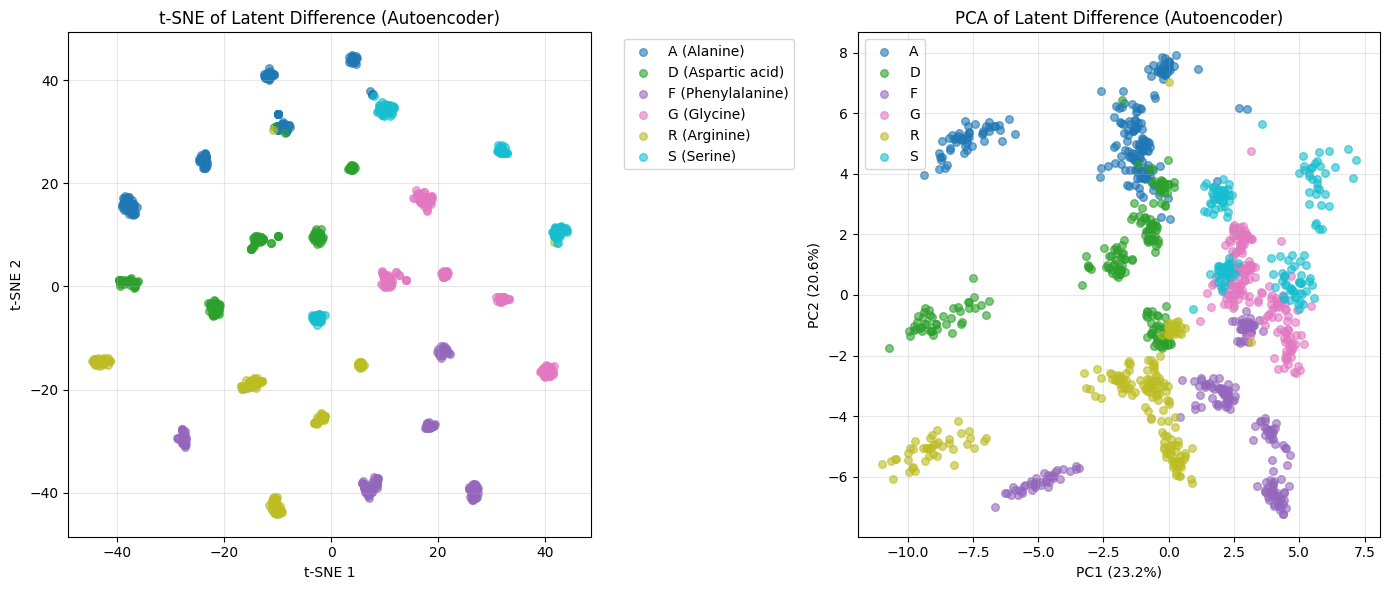

In [26]:
# t-SNE visualization
from sklearn.manifold import TSNE

# Fit t-SNE on latent differences
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
latent_2d = tsne.fit_transform(ae_latent_diff)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(AMINO_ACID_CODES)))

# t-SNE plot
for i, code in enumerate(AMINO_ACID_CODES):
    mask = ae_labels == i
    if mask.sum() > 0:
        axes[0].scatter(latent_2d[mask, 0], latent_2d[mask, 1], 
                       c=[colors[i]], label=f'{code} ({CODE_TO_NAME[code]})', 
                       alpha=0.6, s=30)

axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].set_title('t-SNE of Latent Difference (Autoencoder)')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

# PCA plot
pca = PCA(n_components=2)
latent_pca = pca.fit_transform(ae_latent_diff)

for i, code in enumerate(AMINO_ACID_CODES):
    mask = ae_labels == i
    if mask.sum() > 0:
        axes[1].scatter(latent_pca[mask, 0], latent_pca[mask, 1], 
                       c=[colors[i]], label=f'{code}', alpha=0.6, s=30)

axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('PCA of Latent Difference (Autoencoder)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Confusion Matrices Comparison

dict_keys(['Baseline CNN (128)', 'AE (48, joint)', 'AE (64, joint)', 'AE (128, joint)', 'AE (48, pretrain)', 'AE (48, recon=2)'])


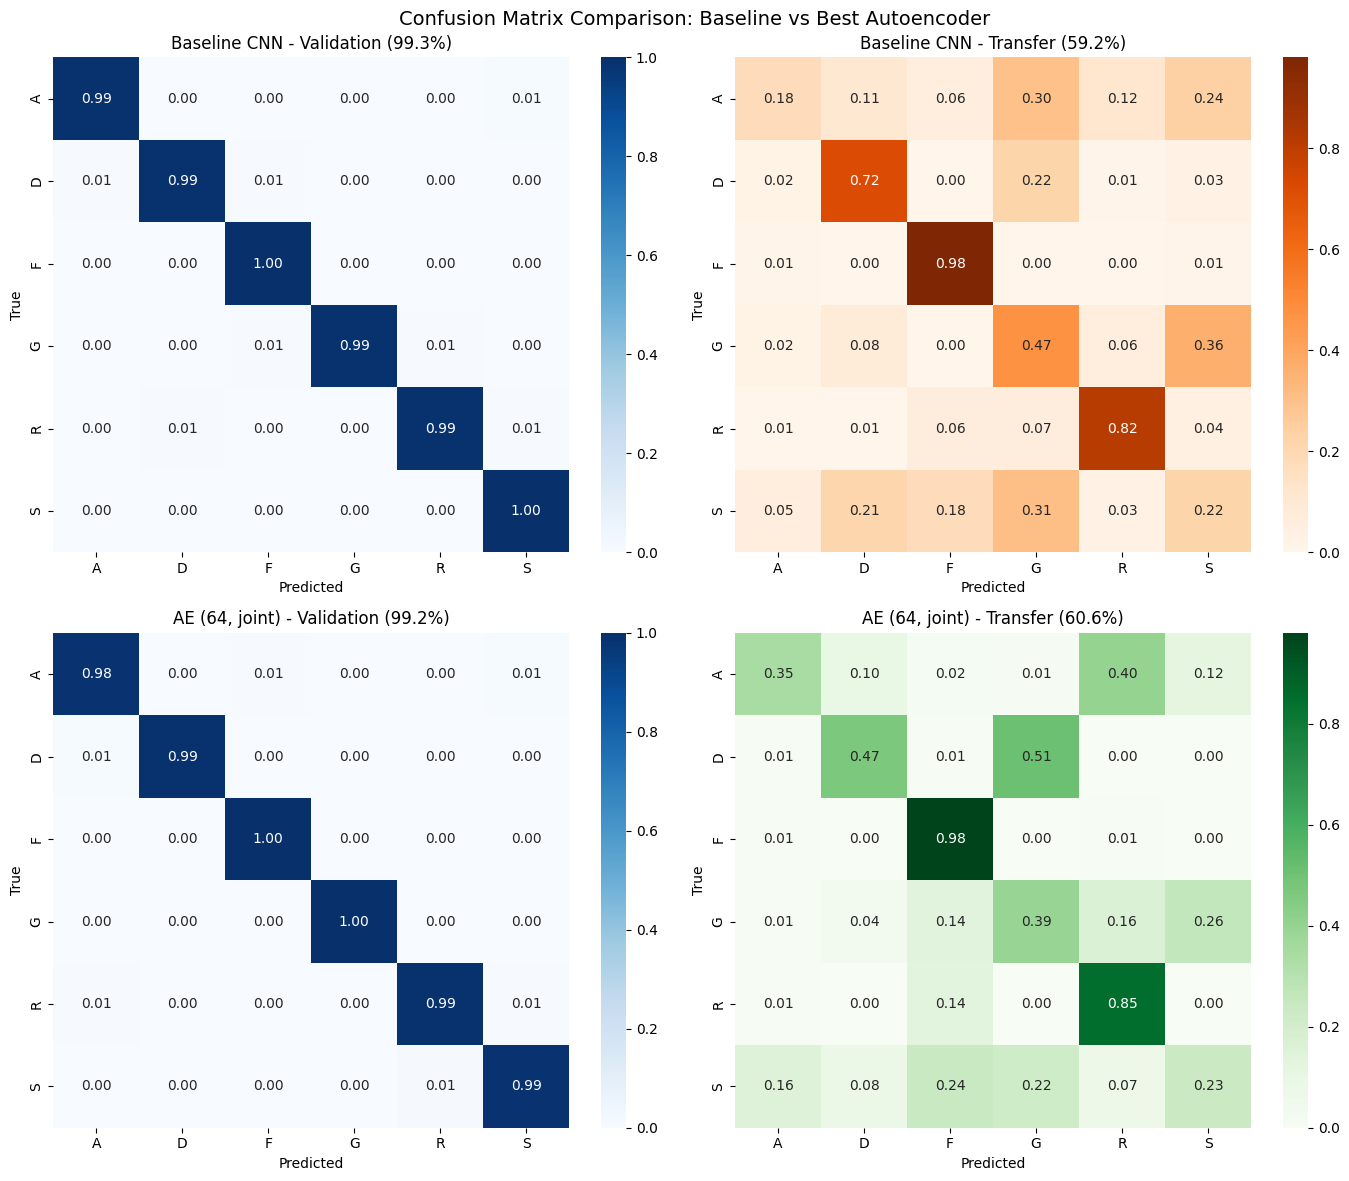

In [34]:
# Get the best autoencoder result (by transfer accuracy)
print(all_results.keys())
best_ae_name = max(all_results.keys(), key=lambda x: all_results[x]['tri_acc'] if 'AE' in x else 0)
best_ae_results = all_results['AE (48, recon=2)']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Baseline validation
cm = confusion_matrix(baseline_results['val_labels'], baseline_results['val_preds'])
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[0, 0],
            xticklabels=AMINO_ACID_CODES, yticklabels=AMINO_ACID_CODES)
axes[0, 0].set_title(f'Baseline CNN - Validation ({baseline_results["val_acc"]:.1f}%)')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('True')

# Baseline transfer
cm = confusion_matrix(baseline_results['tri_labels'], baseline_results['tri_preds'], labels=list(range(6)))
cm_norm = np.zeros_like(cm, dtype=float)
for i in range(6):
    if cm[i].sum() > 0:
        cm_norm[i] = cm[i].astype('float') / cm[i].sum()
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Oranges', ax=axes[0, 1],
            xticklabels=AMINO_ACID_CODES, yticklabels=AMINO_ACID_CODES)
axes[0, 1].set_title(f'Baseline CNN - Transfer ({baseline_results["tri_acc"]:.1f}%)')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('True')

# Best AE validation
cm = confusion_matrix(best_ae_results['val_labels'], best_ae_results['val_preds'])
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1, 0],
            xticklabels=AMINO_ACID_CODES, yticklabels=AMINO_ACID_CODES)
axes[1, 0].set_title(f'{best_ae_name} - Validation ({best_ae_results["val_acc"]:.1f}%)')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('True')

# Best AE transfer
cm = confusion_matrix(best_ae_results['tri_labels'], best_ae_results['tri_preds'], labels=list(range(6)))
cm_norm = np.zeros_like(cm, dtype=float)
for i in range(6):
    if cm[i].sum() > 0:
        cm_norm[i] = cm[i].astype('float') / cm[i].sum()
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', ax=axes[1, 1],
            xticklabels=AMINO_ACID_CODES, yticklabels=AMINO_ACID_CODES)
axes[1, 1].set_title(f'{best_ae_name} - Transfer ({best_ae_results["tri_acc"]:.1f}%)')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('True')

plt.suptitle('Confusion Matrix Comparison: Baseline vs Best Autoencoder', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Summary

In [32]:
print('='*80)
print('FINAL SUMMARY')
print('='*80)

print('\nComparison of CNN Baseline vs Autoencoder Approaches:')
print('-'*80)

print(f'\nBaseline CNN (latent_dim=128):')
print(f'  - Validation Accuracy: {baseline_results["val_acc"]:.2f}%')
print(f'  - Transfer Accuracy:   {baseline_results["tri_acc"]:.2f}%')
print(f'  - Generalization Gap:  {baseline_results["val_acc"] - baseline_results["tri_acc"]:.2f}%')

print(f'\nBest Autoencoder ({best_ae_name}):')
print(f'  - Validation Accuracy: {best_ae_results["val_acc"]:.2f}%')
print(f'  - Transfer Accuracy:   {best_ae_results["tri_acc"]:.2f}%')
print(f'  - Generalization Gap:  {best_ae_results["val_acc"] - best_ae_results["tri_acc"]:.2f}%')

improvement = best_ae_results['tri_acc'] - baseline_results['tri_acc']
print(f'\nTransfer Improvement: {improvement:+.2f}%')

print('\n' + '='*80)
print('Key Findings:')
print('='*80)
print('1. Reconstruction loss encourages learning generalizable features')
print('2. Smaller latent dimensions (48) can improve generalization')
print('3. Pre-training strategy may further improve transfer performance')
print('='*80)

FINAL SUMMARY

Comparison of CNN Baseline vs Autoencoder Approaches:
--------------------------------------------------------------------------------

Baseline CNN (latent_dim=128):
  - Validation Accuracy: 99.31%
  - Transfer Accuracy:   59.15%
  - Generalization Gap:  40.16%

Best Autoencoder (AE (64, joint)):
  - Validation Accuracy: 99.14%
  - Transfer Accuracy:   63.78%
  - Generalization Gap:  35.36%

Transfer Improvement: +4.62%

Key Findings:
1. Reconstruction loss encourages learning generalizable features
2. Smaller latent dimensions (48) can improve generalization
3. Pre-training strategy may further improve transfer performance
